In [1]:
!pip install nevergrad

import warnings

import matplotlib.pyplot as plt
import nevergrad
import numpy
import pandas
import scipy.stats
import seaborn
import sklearn.base
import sklearn.compose
import sklearn.inspection
import sklearn.linear_model
import sklearn.model_selection
import sklearn.preprocessing
from IPython.core.display import display

# nevergrad calls SciPy's COBYLA with a tolerance SciPy corrects.
warnings.filterwarnings("ignore", message="COBYLA: Invalid RHOEND")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.3/506.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.2/347.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 6.8 MB/s eta 0:00:00


In [2]:
!wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s ames

remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.94 KiB | 1.94 MiB/s, done.
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 2), reused 8 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 422.90 KiB | 6.93 MiB/s, done.
Resolving deltas: 100% (2/2), done.
✓ ames — 8 fichiers, 4.6M


# Linear Regression

## Univariate Linear Regression

### Introduction

Linear regression is very interesting to code yourself: it isn't too complex, yet it touches on many machine learning concepts.

We'll keep working on the house price data.

Let's switch to Python for a few seconds to load the dataset:

In [3]:
train_df = pandas.read_csv("ames/train.csv", index_col="Id")

In [4]:
display(train_df)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


### Columns Used

In this demonstration, we'll only use one feature, `GrLivArea`, and `SalePrice` as the target.

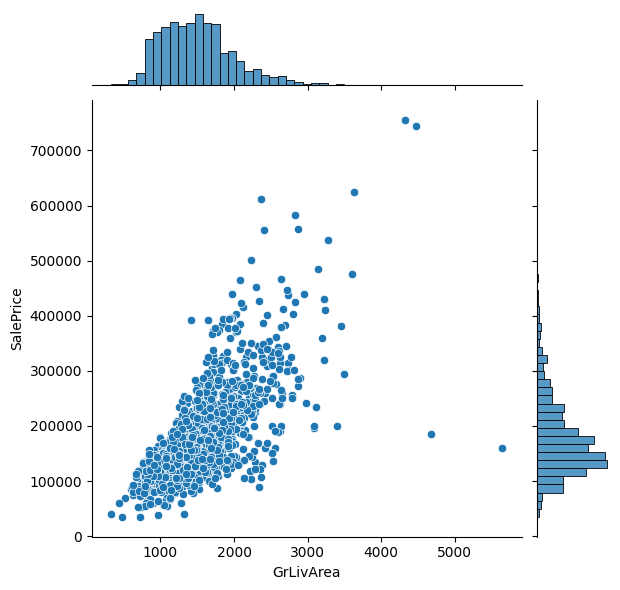

In [5]:
seaborn.jointplot(x="GrLivArea", y="SalePrice", data=train_df)
plt.show()

In [6]:
# Standardize X
X_scaler = sklearn.preprocessing.StandardScaler()
X = X_scaler.fit_transform(train_df[["GrLivArea"]].to_numpy())

# Standardize y
Y_scaler = sklearn.preprocessing.StandardScaler()
Y = Y_scaler.fit_transform(train_df[["SalePrice"]])

### Linear Regression Example
To understand the joint evolution of a house's sale price and overall quality, we'll restrict ourselves to a strong hypothesis: we can find an affine function that correctly models the relationship between inputs and outputs. As a reminder, an affine function has the form $h_\theta(x) = \theta_0 + \theta_1 x$.

Geometrically, this function can be represented by a line.

For instance, here, we'd like to find the following hypothesis:

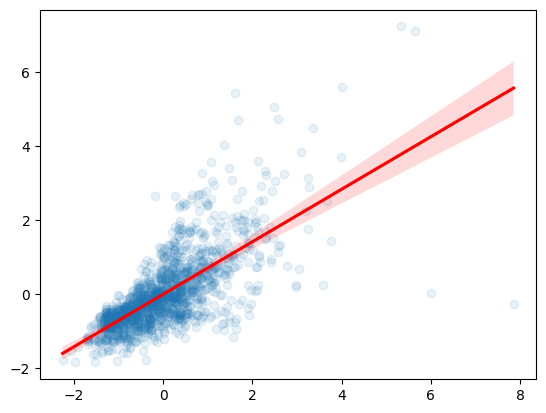

In [7]:
seaborn.regplot(x=X, y=Y, scatter_kws=dict(alpha=0.10), line_kws=dict(color="red"))
plt.show()

This is very well but here we used [`seaborn`](https://seaborn.pydata.org/) to compute our hypothesis. Let's do that from scratch now.

### Estimating the Parameters

To estimate $\theta_0$ and $\theta_1$, we need 2 things:

- a cost function, which tells us, for given parameters $\theta_0$ and $\theta_1$, whether we're doing well or not
- a method to estimate the best parameters given this cost function

### Predictions

As a prerequisite to computing the cost function, we need to know how to compute predictions.

To apply the linear transformation defined by $\theta_0$ and $\theta_1$ to $\mathbf{x}$, we simply use the multiplication and addition of scalars to a vector: $\mathbf{x}\theta_1 + \theta_0$

In [8]:
def predict(X: numpy.ndarray, theta_0: float, theta_1: float) -> numpy.ndarray:
  return theta_0 + X * theta_1


X_example = numpy.array([[1], [2], [3]])
Y_example = numpy.array([[4], [10], [3]])
theta_0_example = 2
theta_1_example = 3

print(predict(X_example, theta_0_example, theta_1_example))

[[ 5]
 [ 8]
 [11]]


### Cost Function

The most widely used cost function is the mean of the squared differences between the actual points and those obtained by the hypothesis with the current parameters.

Denoting $L$ the cost function and $n$ the number of training examples, we can write:

$$
  L(\theta_0, \theta_1) = \sum\frac{(\mathbf{x}\theta_1 + \theta_0 - \mathbf{y})^2}{2n}
$$

In [9]:
def residuals(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  theta_0: float,
  theta_1: float,
) -> numpy.ndarray:
  return predict(X, theta_0, theta_1) - Y


print("Residuals:", residuals(X_example, Y_example, theta_0_example, theta_1_example))


def cost(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  theta_0: float,
  theta_1: float,
) -> numpy.float32:
  return numpy.mean(residuals(X=X, Y=Y, theta_0=theta_0, theta_1=theta_1) ** 2) / 2


print("Costs:", cost(X_example, Y_example, theta_0_example, theta_1_example))

Residuals: [[ 1]
 [-2]
 [ 8]]
Costs: 11.5


### Optimizing the Parameters

Optimizing the parameters means minimizing the cost function:

$$\min_{\theta} \sum\frac{(\theta_0 + \mathbf{x}\theta_1 - \mathbf{y})^2}{2n}$$

There's a closed-form formula for this, which we won't use in this lab for two reasons: it doesn't apply to very large datasets, and the method we'll use can be reused for logistic regression and other techniques (general neural networks, gradient boosted trees, etc).

We'll use gradient descent. This iterative method takes successive steps following the derivative (to maximize) or its opposite (to minimize) of the loss function. In the case of linear regression, it converges to the global optimum (the best solution).

In pseudo-code, the algorithm is (with the right gradients computed):

$$
\begin{aligned}
& \text{while not converged:} \\
& \quad \theta_0 \leftarrow \theta_0 - \alpha \sum\frac{\theta_0 + \mathbf{x}\theta_1 - \mathbf{y}}{n} \\
& \quad \theta_1 \leftarrow \theta_1 - \alpha \frac{\mathbf{x}^T(\theta_0 + \mathbf{x}\theta_1 - \mathbf{y})}{n} \\
\end{aligned}
$$

where $\alpha$ is the learning rate.

In [10]:
def gradient(
  X: numpy.ndarray, Y: numpy.ndarray, theta_0: float, theta_1: float
) -> tuple[float, float]:
  r = residuals(X=X, Y=Y, theta_1=theta_1, theta_0=theta_0)
  g_0 = r.mean()
  g_1 = X.T.dot(r) / Y.size
  return g_0, g_1[0, 0]

### Gradient Descent

In [11]:
def gradient_descent(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  alpha: float = 0.1,
  nb_iter: int = 1000,
  epsilon: float = 10e-6,
) -> tuple[float, float, list[float]]:
  theta_0 = numpy.random.rand(1)[0]
  theta_1 = numpy.random.rand(1)[0]
  print(f"Initial (random) parameters: θ₀ = {theta_0:.2f}, θ₁ = {theta_1:.2f}")
  initial_cost = cost(X, Y, theta_0, theta_1)
  print(f"Initial cost: {initial_cost:.2f}")
  costs = [initial_cost]
  for i in range(nb_iter):
    g_0, g_1 = gradient(X, Y, theta_0, theta_1)
    theta_0 -= alpha * g_0
    theta_1 -= alpha * g_1
    costs.append(cost(X, Y, theta_0, theta_1))
    if costs[-2] - costs[-1] < epsilon:
      print(f"Stopping: not enough progress at iteration {i}")
      break
  print(f"Final parameters: θ₀ = {theta_0:.2f}, θ₁ = {theta_1:.2f}")
  print(f"Final cost: {costs[-1]:.2f}")
  return theta_0, theta_1, costs


theta_0, theta_1, costs = gradient_descent(X, Y, 0.1, 1000)
print(f"Successive costs:  {', '.join(map(str, costs))}")

Initial (random) parameters: θ₀ = 0.97, θ₁ = 0.94
Initial cost: 0.75
Stopping: not enough progress at iteration 44
Final parameters: θ₀ = 0.01, θ₁ = 0.71
Final cost: 0.25
Successive costs:  0.7482445454086722, 0.6533739600052032, 0.5765287858283932, 0.5142841947451771, 0.4638660759677721, 0.42302739975807396, 0.3899480720282185, 0.36315381656703555, 0.3414504696434774, 0.3238707586353953, 0.30963119271884876, 0.2980971443264461, 0.2887545651286, 0.2811870759783445, 0.2750574097666377, 0.2700923801351551, 0.26607070613365424, 0.2628131501924385, 0.2601745298800538, 0.25803724742702216, 0.25630604864006656, 0.2549037776226325, 0.2537679380985109, 0.25284790808397245, 0.25210268377219625, 0.25149905207965756, 0.2510101104087012, 0.2506140676552266, 0.25029327302491217, 0.2500334293743574, 0.2498229560174081, 0.24965247259827916, 0.24951438102878468, 0.2494025268574942, 0.24931192497874888, 0.24923853745696523, 0.2491790935643204, 0.24913094401127814, 0.24909194287331385, 0.249060351951562

To finish, the call to the gradient_descent function

In [12]:
theta_0, theta_1, costs = gradient_descent(X, Y, 0.01, 5000, 10e-6)

Initial (random) parameters: θ₀ = 0.33, θ₁ = 0.26
Initial cost: 0.40
Stopping: not enough progress at iteration 286
Final parameters: θ₀ = 0.02, θ₁ = 0.68
Final cost: 0.25


### Checking Our Hypothesis

Let's now check the trained model with a few plots:

- predicted values against actual values
- residuals
- training costs

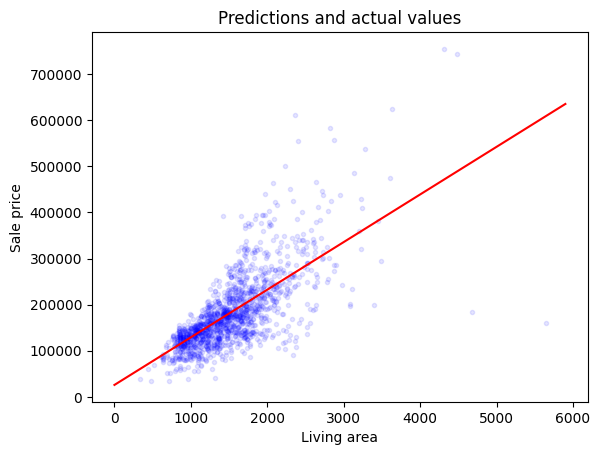

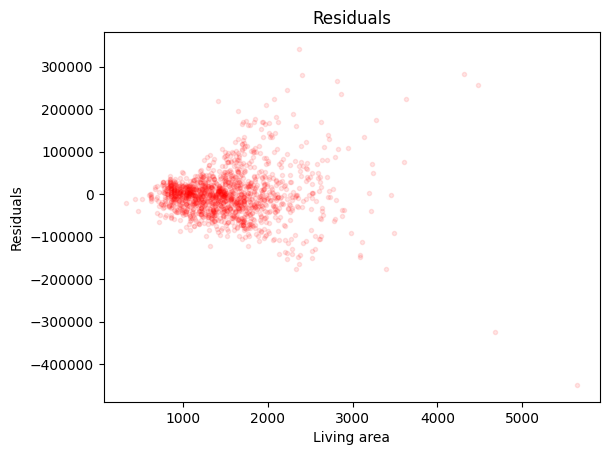

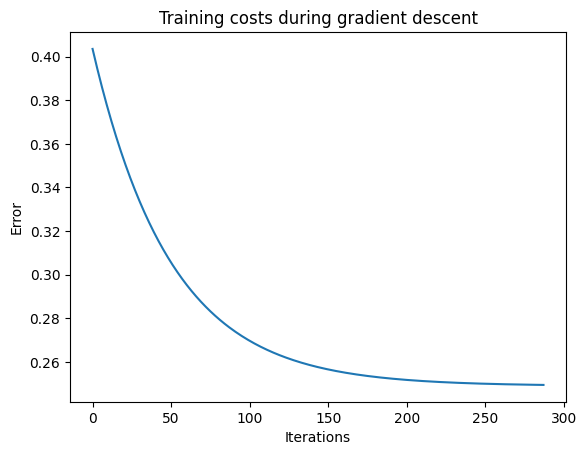

In [13]:
inv_X = X_scaler.inverse_transform(X)
inv_Y = Y_scaler.inverse_transform(Y)
inv_Yh = Y_scaler.inverse_transform(predict(X, theta_0, theta_1))

Xs = numpy.arange(0, 6_000, 100).reshape(-1, 1)
Ys = Y_scaler.inverse_transform(predict(X_scaler.transform(Xs), theta_0, theta_1))
plt.plot(inv_X, inv_Y, "b.", alpha=0.10)
plt.plot(Xs, Ys, "r")
plt.title("Predictions and actual values")
plt.xlabel("Living area")
plt.ylabel("Sale price")
plt.show()

plt.plot(inv_X, inv_Y - inv_Yh, "r.", alpha=0.10)
plt.title("Residuals")
plt.xlabel("Living area")
plt.ylabel("Residuals")
plt.show()

plt.plot(range(len(costs)), costs)
plt.title("Training costs during gradient descent")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.show()

### Correcting the Positive Skew

It's useful to correct the positive skew of the output variable if we've noticed it: we can use the [`numpy.log1p`](https://numpy.org/doc/stable/reference/generated/numpy.log1p.html) function and its inverse transformation [`numpy.expm1`](https://numpy.org/doc/stable/reference/generated/numpy.expm1.html).

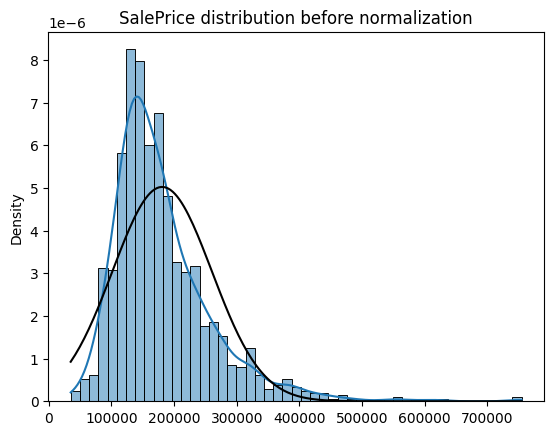

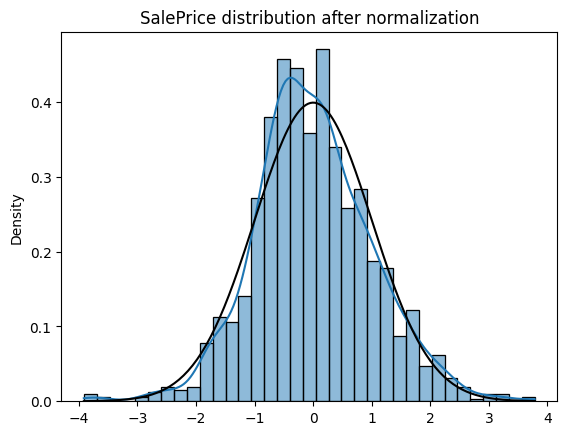

In [14]:
def plot_with_normal_fit(values):
  values = numpy.ravel(values)
  seaborn.histplot(values, stat="density", kde=True)
  xs = numpy.linspace(values.min(), values.max(), 200)
  plt.plot(xs, scipy.stats.norm.pdf(xs, *scipy.stats.norm.fit(values)), "k")


plot_with_normal_fit(train_df["SalePrice"])
plt.title("SalePrice distribution before normalization")
plt.show()

Y_scaler_log = sklearn.preprocessing.StandardScaler()
Y = Y_scaler_log.fit_transform(numpy.log1p(train_df[["SalePrice"]]))

plot_with_normal_fit(Y)
plt.title("SalePrice distribution after normalization")
plt.show()

Initial (random) parameters: θ₀ = 1.00, θ₁ = 0.78
Initial cost: 0.75
Stopping: not enough progress at iteration 344
Final parameters: θ₀ = 0.03, θ₁ = 0.70
Final cost: 0.25


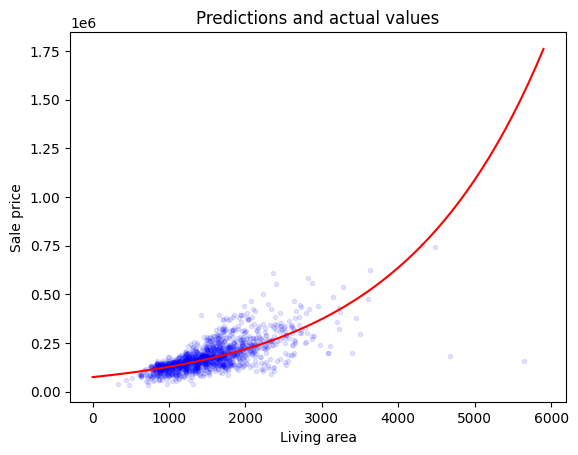

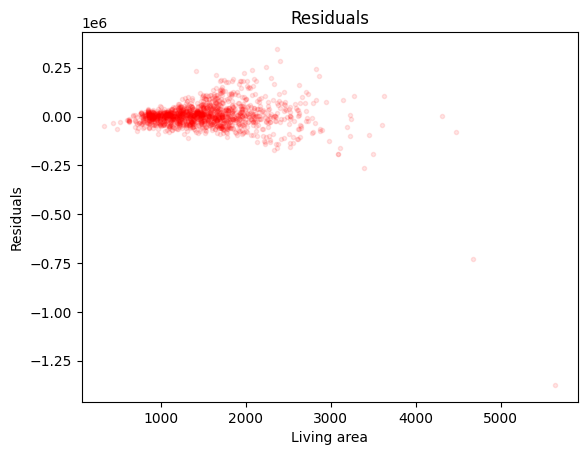

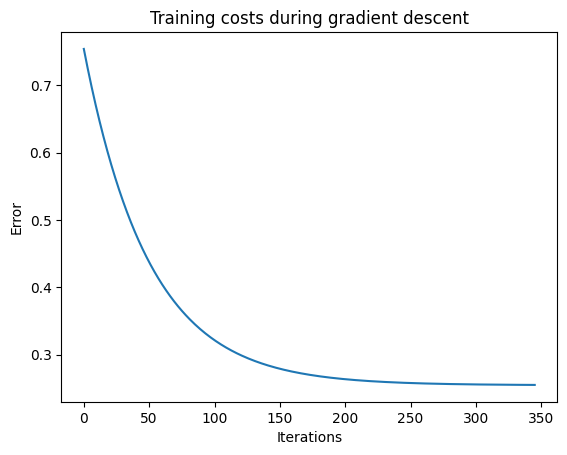

In [15]:
theta_0, theta_1, costs = gradient_descent(X, Y, 0.01, 5000, 10e-6)

inv_X = X_scaler.inverse_transform(X)
inv_Y = numpy.expm1(Y_scaler_log.inverse_transform(Y))
inv_Yh = numpy.expm1(Y_scaler_log.inverse_transform(predict(X, theta_0, theta_1)))

Xs = numpy.arange(0, 6_000, 100).reshape(-1, 1)
Ys = numpy.expm1(
  Y_scaler_log.inverse_transform(predict(X_scaler.transform(Xs), theta_0, theta_1))
)
plt.plot(inv_X, inv_Y, "b.", alpha=0.10)
plt.plot(Xs, Ys, "r")
plt.title("Predictions and actual values")
plt.xlabel("Living area")
plt.ylabel("Sale price")
plt.show()

plt.plot(inv_X, inv_Y - inv_Yh, "r.", alpha=0.10)
plt.title("Residuals")
plt.xlabel("Living area")
plt.ylabel("Residuals")
plt.show()

plt.plot(range(len(costs)), costs)
plt.title("Training costs during gradient descent")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.show()

## Multivariate linear regression

To continue this demonstration, we'll take up a complete preprocessing of all the AMES data (and not only the `GrLiveArea` column).

In [16]:
def preprocess(train_file: str, test_file: str) -> numpy.ndarray:
  train_X = pandas.read_csv(train_file, index_col="Id")
  test_X = pandas.read_csv(test_file, index_col="Id")

  train_Y = train_X[["SalePrice"]]
  train_X = train_X.drop(columns="SalePrice")

  all_X = pandas.concat([train_X, test_X])

  # Fill with median
  cols_1 = ["LotFrontage"]
  all_X[cols_1] = all_X[cols_1].fillna(train_X[cols_1].median())

  # Fill with mode
  cols_2 = [
    "MSZoning",
    "Electrical",
    "KitchenQual",
    "Exterior1st",
    "Exterior2nd",
    "SaleType",
    "Utilities",
  ]
  all_X[cols_2] = all_X[cols_2].fillna(train_X[cols_2].mode().iloc[0, :])

  # Fill with 0
  cols_4 = [
    "GarageYrBlt",
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtFullBath",
    "BsmtHalfBath",
    "BsmtUnfSF",
    "MasVnrArea",
    "TotalBsmtSF",
  ]
  all_X[cols_4] = all_X[cols_4].fillna(0)

  # Other fills
  cols_5 = ["Functional"]
  all_X[cols_5] = all_X[cols_5].fillna("Typ")

  # Give all other NAs the string value NA, which will be a category
  all_X = all_X.fillna("NA")

  # Turn the numerical codes into strings so that they're treated as
  # a categorical variable
  cols_numerical2label = ["MSSubClass"]
  all_X[cols_numerical2label] = all_X[cols_numerical2label].astype(str)

  quality_mapping = dict(NA=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5)
  quality_columns = [
    "BsmtCond",
    "BsmtQual",
    "ExterCond",
    "ExterQual",
    "FireplaceQu",
    "GarageCond",
    "GarageQual",
    "HeatingQC",
    "KitchenQual",
    "PoolQC",
  ]
  street_mapping = dict(NA=0, Grvl=1, Pave=2)
  bsmt_fin_mapping = dict(NA=0, Unf=1, LwQ=2, Rec=3, BLQ=4, ALQ=5, GLQ=6)

  replace_mapping = dict(
    Alley=street_mapping,
    BsmtExposure=dict(NA=0, No=1, Mn=2, Av=3, Gd=4),
    BsmtFinType1=bsmt_fin_mapping,
    BsmtFinType2=bsmt_fin_mapping,
    Functional=dict(Sal=1, Sev=2, Maj2=3, Maj1=4, Mod=5, Min2=6, Min1=7, Typ=8),
    LandSlope=dict(Sev=1, Mod=2, Gtl=3),
    LotShape=dict(IR3=1, IR2=2, IR1=3, Reg=4),
    PavedDrive=dict(NA=0, N=1, P=2, Y=3),
    Street=dict(Grvl=1, Pave=2),
    Utilities=dict(ELO=1, NoSeWa=2, NoSewr=3, AllPub=4),
  )

  for quality_column in quality_columns:
    replace_mapping[quality_column] = quality_mapping

  with pandas.option_context("future.no_silent_downcasting", True):
    all_X = all_X.replace(replace_mapping).infer_objects()

  print(f"Number of NAs: {all_X.isnull().sum().sum()}")

  dummies = pandas.get_dummies(all_X)
  return (
    dummies.iloc[: train_X.shape[0], :].values,
    train_Y.values,
    dummies.iloc[train_X.shape[0] :, :].values,
    dummies.columns,
  )

In [17]:
X_train, Y_train, X_test, columns = preprocess(
  "ames/train.csv", "ames/test.csv"
)

Number of NAs: 0


### Normalizing the Output Variable

Let's use [`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) to center and scale the targets into the new variable `Y_train_scaled`.

In [18]:
Y_scaler = sklearn.preprocessing.StandardScaler()
Y_train_scaled = Y_scaler.fit_transform(Y_train)

### Training a Simple Linear Regression Model

In [19]:
linear_regression = sklearn.linear_model.LinearRegression()
linear_regression.fit(X_train, Y_train_scaled)
print(linear_regression.coef_)

[[ 1.22179619e-03  5.70932927e-06  2.55879803e-01  1.21915529e-02
   1.98410729e-03  3.47709848e-01  2.03622459e-03  1.04347088e-01
   6.65812752e-02  3.24579052e-03  2.25214686e-04  4.06189830e-04
   6.30410585e-02 -3.75551964e-02  3.95141767e-02 -6.43925794e-02
   6.41880657e-02 -2.44423853e-03  2.20866024e-04  5.87414740e-03
   4.05658993e-05 -3.53453092e-05  2.26086517e-04  1.48090735e-02
   1.85727068e-04  3.76903696e-04 -1.47913433e-04  4.14717094e-04
   2.18214584e-02  9.69407397e-03  4.79675575e-02  3.90451678e-02
  -7.52814442e-02 -1.70551664e-01  8.68333263e-02  3.69298468e-02
   7.72120324e-02  7.26221548e-02 -2.04123091e-02 -1.57297137e-04
   5.98516609e-02  2.02987388e-04  7.79043854e-02 -1.94643196e-02
  -3.87647251e-03  1.57053912e-04  1.68359086e-04 -1.49201312e-05
   5.30774435e-04  5.47906740e-04 -3.99136252e-04  2.89212138e-01
   2.87349546e-05 -9.04370425e-03 -5.97791984e-04 -8.35879560e-02
  -1.55431223e-14 -2.50530468e-02 -9.73326888e-02 -2.71575744e-01
   1.09088

### Cross-Validation

In [20]:
def score(
  model: sklearn.base.BaseEstimator,
  X: numpy.ndarray = X_train,
  Y: numpy.ndarray = Y_train_scaled,
):
  scores = sklearn.model_selection.cross_val_score(model, X, Y, cv=5, scoring="r2")
  return sum(scores) / len(scores)


def score(
  model: sklearn.base.BaseEstimator,
  X: numpy.ndarray = X_train,
  Y: numpy.ndarray = Y_train_scaled,
) -> float:
  pipeline = sklearn.compose.TransformedTargetRegressor(
    regressor=model, transformer=sklearn.preprocessing.StandardScaler()
  )
  scores = sklearn.model_selection.cross_val_score(pipeline, X, Y, cv=5, scoring="r2")
  return sum(scores) / len(scores)


score(sklearn.linear_model.LinearRegression())

np.float64(0.7987596594537081)

### L1 and L2 Regularization

In [21]:
score_l1 = score(sklearn.linear_model.Lasso())
score_l2 = score(sklearn.linear_model.Ridge())
score_l1_l2 = score(sklearn.linear_model.ElasticNet())
print("l1, l2 and l1+l2 scores:", score_l1, score_l2, score_l1_l2)

l1, l2 and l1+l2 scores: 0.7238187274474043 0.8254888460148259 0.7261933076864522


### Hyperparameter Search

`scikit-learn` contains a few hyperparameter search algorithms, but they're fairly limited (random search & grid search). Several third-party libraries are available to provide this feature.

In [22]:
# Simple model
model = sklearn.linear_model.Ridge()
params = dict(alpha=[1e-3, 1e-2, 1e-1, 1, 1e2, 1e3])
rscv = sklearn.model_selection.RandomizedSearchCV(
  model, params, scoring="r2", n_iter=6, verbose=0
)
search = rscv.fit(X_train, Y_train_scaled)
print("=" * 80)
print(f"Parameters found by RSCV: {search.best_params_}")
print(f"score: {search.best_score_}")
print("=" * 80)

# Complex model that uses a transformation of the targets
model = sklearn.compose.TransformedTargetRegressor(
  regressor=sklearn.linear_model.Ridge(),
  transformer=sklearn.preprocessing.StandardScaler(),
)
params = dict(regressor__alpha=[1e-3, 1e-2, 1e-1, 1, 1e2, 1e3])
rscv = sklearn.model_selection.RandomizedSearchCV(
  model, params, scoring="r2", n_iter=6, verbose=0
)
search = rscv.fit(X_train, Y_train)
print("=" * 80)
print(f"Parameters found by RSCV: {search.best_params_}")
print(f"score: {search.best_score_}")
print("=" * 80)


# With Nevergrad
def loss(alpha: float) -> float:
  return -score(sklearn.linear_model.Ridge(alpha=alpha))


parametrization = nevergrad.p.Instrumentation(
  alpha=nevergrad.p.Scalar(lower=1e-3, upper=1e3),
)

optimizer = nevergrad.optimizers.NGOpt(parametrization=parametrization, budget=50)
recommendation = optimizer.minimize(loss, verbosity=0)

best_model = sklearn.linear_model.Ridge(**recommendation.kwargs)
best_model.fit(X_train, Y_train_scaled)
print()
print("=" * 80)
print(f"Parameters found by Nevergrad: {recommendation.kwargs}")
print(f"score: {score(best_model)}")
print("=" * 80)

Parameters found by RSCV: {'alpha': 1}
score: 0.8254888460148255
Parameters found by RSCV: {'regressor__alpha': 1}
score: 0.8254888460148259

Parameters found by Nevergrad: {'alpha': 12.141987858999894}
score: 0.8302101262740884


### Feature Importance

Let's use scikit-learn's permutation importance ([`sklearn.inspection.permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html)) to evaluate which features are the most useful to the best model trained after the hyperparameter search.

In [23]:
feature_importances = sklearn.inspection.permutation_importance(
  best_model, X_train, Y_train_scaled, n_repeats=50
)

<Axes: >

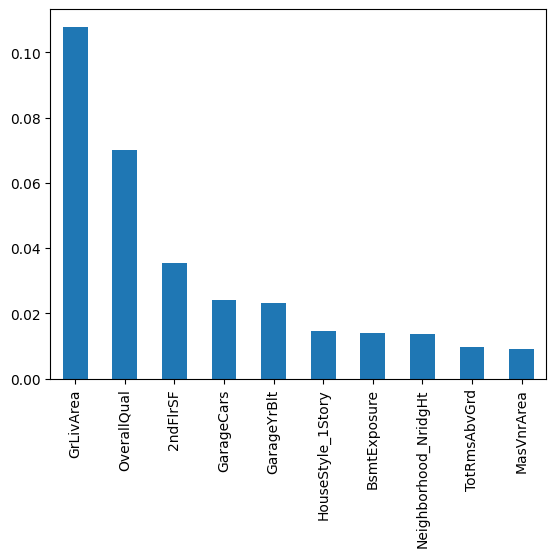

In [24]:
series = pandas.Series(feature_importances.importances_mean, index=columns)
series = series.sort_values(ascending=False).iloc[:10]
series.plot.bar()

### Polynomial Features

Besides manually extending the features, you can use scikit-learn to extend the training matrix with polynomial features, with its [`sklearn.preprocessing.PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) class.

In [25]:
top10 = (-feature_importances.importances_mean).argsort()[:10]


def poly_features(array: numpy.ndarray) -> numpy.ndarray:
  polynomial_features = sklearn.preprocessing.PolynomialFeatures(
    2, interaction_only=True
  )
  return polynomial_features.fit_transform(array[:, top10])


X_train_poly = poly_features(X_train)
X_test_poly = poly_features(X_test)


parametrization = nevergrad.p.Instrumentation(
  alpha=nevergrad.p.Scalar(lower=1e-3, upper=1e3),
)

optimizer = nevergrad.optimizers.NGOpt(parametrization=parametrization, budget=50)
recommendation = optimizer.minimize(loss, verbosity=0)

best_model = sklearn.linear_model.Ridge(**recommendation.kwargs)
best_model.fit(X_train_poly, Y_train_scaled)

print()
print("=" * 80)
print(f"Parameters found by Nevergrad: {recommendation.kwargs}")
print(f"score: {score(best_model)}")
print("=" * 80)


Parameters found by Nevergrad: {'alpha': 12.141987858999894}
score: 0.8302101262740884
